## A8

**Data Analytics 1**

**Linear Regression**

**BOSTON HOUSING DATASET**

In [308]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [309]:
df = pd.read_csv("BostonHousing.csv")

In [310]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [311]:
df.shape

(506, 14)

In [312]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [314]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [315]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

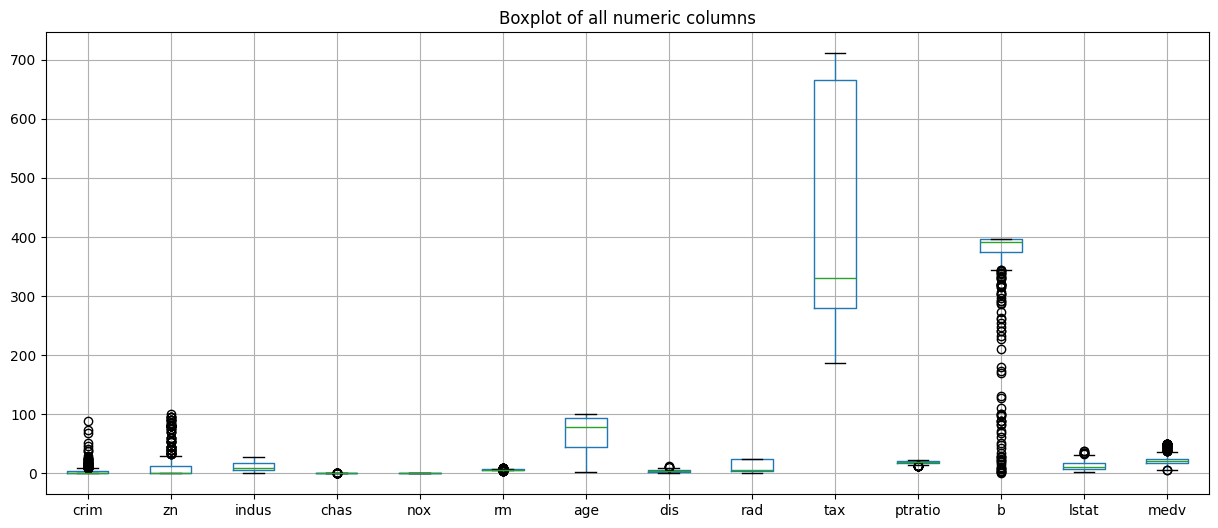

In [316]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.title("Boxplot of all numeric columns")
plt.show()

Inference: outliers exists in many columns

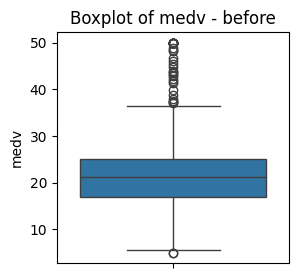

In [317]:
plt.figure(figsize=(3,3))
plt.title("Boxplot of medv - before")
sns.boxplot(df["medv"])
plt.show()

In [318]:
Q1 = df["medv"].quantile(0.25)
Q3 = df["medv"].quantile(0.75)
IQR = Q3 - Q1
l = Q1 - (1.5 * IQR)
u = Q3 + (1.5 * IQR)

In [319]:
df = df[(df["medv"] >= l) & (df["medv"] <= u)]
df.shape

(466, 14)

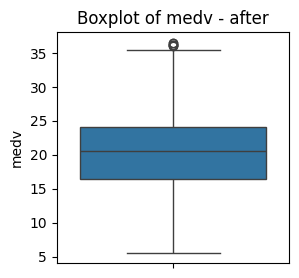

In [320]:
plt.figure(figsize=(3,3))
plt.title("Boxplot of medv - after")
sns.boxplot(df["medv"])
plt.show()

CORRELATION

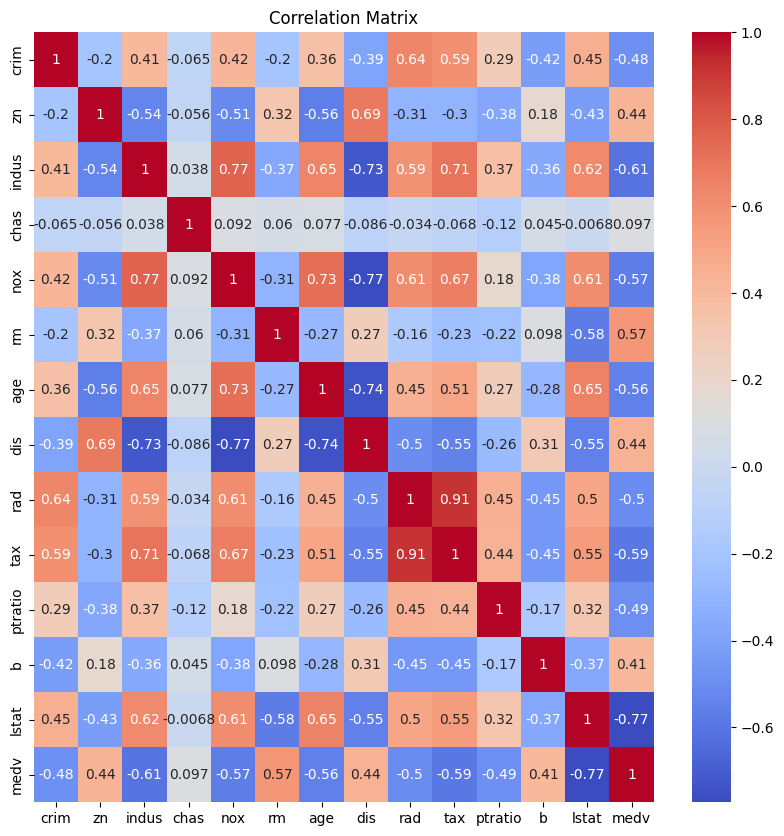

In [321]:
plt.figure(figsize=(10,10))
plt.title("Correlation Matrix")
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Inference:
    
    rm: pos corr

    lstat: neg corr

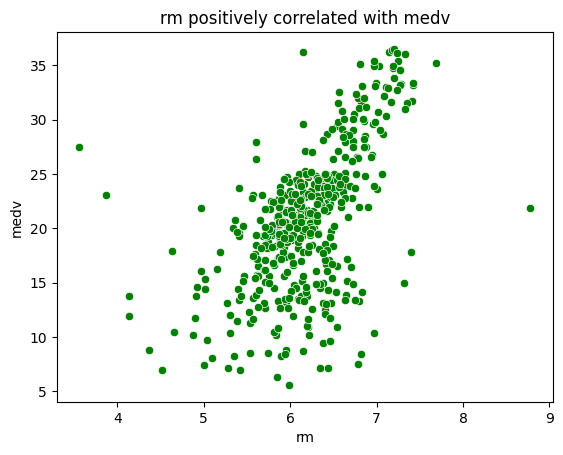

In [322]:
sns.scatterplot(x="rm", y="medv", data=df, color='green')
plt.title("rm positively correlated with medv")
plt.show()

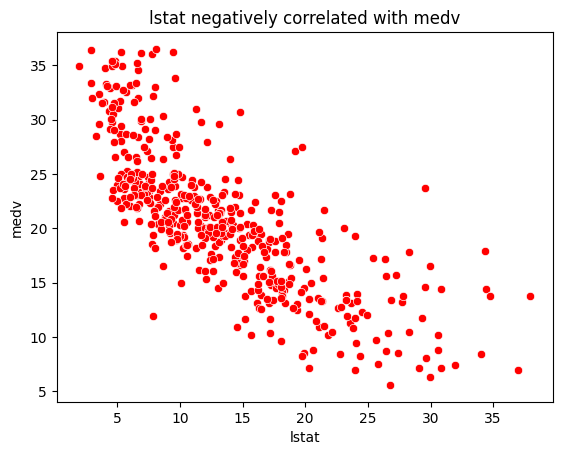

In [323]:
sns.scatterplot(x="lstat", y="medv", data=df, color='red')
plt.title("lstat negatively correlated with medv")
plt.show()

LINEAR MODEL

In [324]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [325]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [326]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [327]:
model = LinearRegression()

In [328]:
model.fit(X_train, y_train)

LinearRegression()

In [329]:
y_pred = model.predict(X_test)

In [330]:
print(y_pred)

[29.22649305 22.61677    15.95717457 22.17226214 24.62601074 14.33271201
 24.33758226 19.94496321 26.51607861 24.8748434  22.75992846 24.34416676
 10.47712599 25.42179667 23.38405261 30.06106408 14.70047642 23.86141474
 19.27550259 21.7974695  27.64668447 27.0690393  21.66204486 17.00339418
 23.08619429 20.86456112 25.79362092 30.30232866 14.26275768 26.93636628
 13.46148604 16.91643853 27.36543969 25.63750822 18.31632228 29.3168732
 22.3809334  25.05056863 15.60241735 15.71148634 19.76979163 20.88696808
 13.74048582 20.05188332 12.65307077 27.13193316 20.66047413 20.19345998
 16.38343774 29.90312363 20.90429982 21.3400036  17.5572487  26.87874387
 16.45298808 18.45792931 21.21696562 20.01861618 12.06015887 19.46497814
 28.68877431 24.00957654 19.54051542 13.87934207 23.99067839 30.03101177
 13.57816209 16.13049075 16.36748178 14.8263071  19.86966451 18.70934257
 12.54086205 19.09801192 16.32201372 15.48743053 24.79169269 29.20790022
 19.60653615 18.08673734 13.4051283  16.55210354  9.

Metrics:

In [331]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE score: ", np.round(mse, 2))
print("RMSE score: ", np.round(rmse, 2))
print("R2 score: ", np.round(r2, 2))

MSE score:  9.93
RMSE score:  3.15
R2 score:  0.75


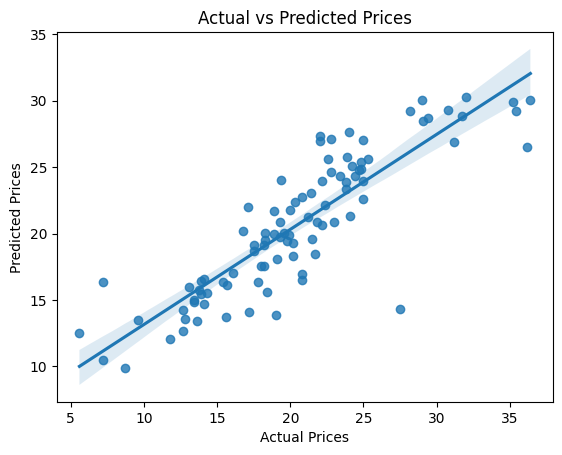

In [332]:
sns.regplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()